In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import os
import sys
import pickle
from scipy.optimize import curve_fit

path = os.getcwd().split(os.sep + 'GUI')[0]
if path not in sys.path:
    print("not here")
    sys.path.append(path)

import neurolib.dashboard.data as data
from neurolib.models.aln import ALNModel
import neurolib.dashboard.layout as layout
import neurolib.dashboard.functions as functions
from neurolib.utils import plotFunctions as plotFunc

# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2    

not here


In [2]:
readpath = '..' + os.sep
savepath = os.path.join(os.getcwd().split('neurolib')[0], 'writing' + os.sep + 'paper1' + os.sep + 'concept' + os.sep + 'images')


with open(readpath + os.sep + 'bi.pickle','rb') as file:
    load_array= pickle.load(file)
ext_exc = load_array[0]
ext_inh = load_array[1]

with open(readpath + os.sep + 'bi_granular.pickle','rb') as file:
    load_array= pickle.load(file)
ext_exc_granular = load_array[0]
ext_inh_granular = load_array[1]

with open(readpath + os.sep + 'boundary_bi_granular.pickle','rb') as file:
    load_array= pickle.load(file)
boundary_exc_granular = load_array[0]
boundary_inh_granular = load_array[1]

grid_resolution = layout.grid_resolution
grid_resolution_granular = layout.grid_resolution_granular

dist_up_regime = np.zeros((len(ext_exc), 2))
dist_down_regime = np.zeros((len(ext_exc)))

cmap = layout.getcolormap()
darkgrey, midgrey, lightgrey, color_bi_updown, color_LC, color_bi_uposc = layout.getcolors()
exc_red = cmap(3)
inh_blue=cmap(0)
green = cmap(2)

aln = ALNModel()
data.set_parameters(aln)
state_vars = aln.state_vars

In [3]:
##############################################################
def setinit(init_vars_, model):
    state_vars = model.state_vars
    init_vars = model.init_vars
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if model.params[init_vars[iv]].ndim == 2:
                    model.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    model.params[init_vars[iv]][0] = init_vars_[sv]
                    
def derivative(f,a,dt):
    return (f[a+1] - f[a])/dt

def fit_func_lin(x, a, b):
    return a * x + b

def fit_func_quad(x, a, b, c):
    return a * x**2 + b * x + c

def setlabels(axc):
    axc[-1,0].set_xlabel('Ext current to exc node')
    axc[-1,1].set_xlabel('Ext current to inh node')
    axc[-1,2].set_xlabel('Distance horizontal')
    axc[-1,3].set_xlabel('Distance vertical')
    axc[-1,4].set_xlabel('Shortest distance')
    axc[-1,5].set_xlabel('Exc target rate difference')
    axc[-1,6].set_xlabel('Inh target rate difference')

    axc[0,0].set_ylabel('Exc amplitude')
    axc[1,0].set_ylabel('Inh amplitude')
    axc[2,0].set_ylabel('Exc sparsity cost')
    axc[3,0].set_ylabel('Inh sparsity cost')
    axc[4,0].set_ylabel('Exc width')
    axc[5,0].set_ylabel('Inh width')

def setlabels_ufp(axc):
    axc[-1,0].set_xlabel('Exc activity of intermediate state')
    axc[-1,1].set_xlabel('Inh activity of intermediate state')
    axc[-1,2].set_xlabel('Difference to low activity (E)')
    axc[-1,3].set_xlabel('Difference to low activity (I)')
    axc[-1,4].set_xlabel('Difference to high activity (E)')
    axc[-1,5].set_xlabel('Difference to ihgh activity (I)')

    axc[0,0].set_ylabel('Exc amplitude')
    axc[1,0].set_ylabel('Inh amplitude')
    axc[2,0].set_ylabel('Exc sparsity cost')
    axc[3,0].set_ylabel('Inh sparsity cost')
    axc[4,0].set_ylabel('Exc width')
    axc[5,0].set_ylabel('Inh width')
    
def setlabels_energy(axc):
    for i in [1, 4, 7]:
        axc[i,0].set_xlabel('Ext current to exc node')
        axc[i,1].set_xlabel('Ext current to inh node')
        axc[i,2].set_xlabel('Distance horizontal')
        axc[i,3].set_xlabel('Distance vertical')
        axc[i,4].set_xlabel('Shortest distance')
        axc[i,5].set_xlabel('Exc target rate difference')
        axc[i,6].set_xlabel('Inh target rate difference')

    axc[0,0].set_ylabel('Exc amplitude')
    axc[1,0].set_ylabel('Inh amplitude')
    axc[3,0].set_ylabel('Exc energy cost')
    axc[4,0].set_ylabel('Inh energy cost')
    axc[6,0].set_ylabel('Exc width')
    axc[7,0].set_ylabel('Inh width')
    
    for x in [2, 5, 8]:
        for y in [0,1]:
            axc[x,y].set_xlabel('Shortest distance')
            
    axc[2,2].set_xlabel('Inh amplitude')
    axc[2,0].set_ylabel('Amplitude sum')
    axc[2,1].set_ylabel('Amplitude geometric sum')
    axc[2,2].set_ylabel('Exc amplitude')
    
    axc[5,2].set_xlabel('Inh energy cost')
    axc[5,0].set_ylabel('Energy cost sum')
    axc[5,1].set_ylabel('Energy cost geometric sum')
    axc[5,2].set_ylabel('Exc energy cost')
    axc[5,3].set_xlabel('Total cost')
    axc[5,3].set_ylabel('Exc cost')
    axc[5,4].set_xlabel('Total cost')
    axc[5,4].set_ylabel('Inh cost')
    
    axc[8,2].set_xlabel('Inh width')
    axc[8,0].set_ylabel('Width sum')
    axc[8,1].set_ylabel('Width geometric sum')
    axc[8,2].set_ylabel('Exc width')

def readcase(case_):
    
    global ind_, type_, mu_e, mu_i, a_e, a_i, cost_node, w_e, w_i, target_high, target_low 
    global d_e, d_i, d_total, ufp_e, ufp_i
    global cost_p_x, cost_p_y, cost_s_x, cost_e_x, cost_s_y, cost_e_y
    global target_h_e, target_h_i, target_l_e, target_l_i, target_diff_e, target_diff_i
    
    readpath = '..' + os.sep + 'data_final' + os.sep
    
    data_array = data.read_data_1(aln, readpath, case_)
    ind_, type_, mu_e, mu_i, a_e, a_i, cost_node, w_e, w_i, target_high, target_low = data_array
    
    opt_control = [None] * len(ind_)
    opt_state = [None] * len(ind_)
    
    control_data = data.read_control(readpath, case_)
    opt_control = control_data[2]
    opt_state = control_data[3]
        
    d_e = [None] * len(ind_)
    d_i = [None] * len(ind_)
    d_total = [None] * len(ind_)
    ufp_e = [None] * len(ind_)
    ufp_i = [None] * len(ind_)

    target_h_e = [None] * len(ind_)
    target_h_i = [None] * len(ind_)
    target_l_e = [None] * len(ind_)
    target_l_i = [None] * len(ind_)
    target_diff_e = [None] * len(ind_)
    target_diff_i = [None] * len(ind_)
    
    cost_p_x = [None] * len(ext_exc)
    cost_p_y = [None] * len(ext_exc)
    cost_s_x = [None] * len(ext_exc)
    cost_e_x = [None] * len(ext_exc)
    cost_s_y = [None] * len(ext_exc)
    cost_e_y = [None] * len(ext_exc)
    
    for i in ind_:
        
        if type(opt_control[i]) == type(None):
            continue
    
        if case_ in ['1', '2']:
            d_e[i] = data.dist_right(mu_e[i], mu_i[i], ext_exc_granular, ext_inh_granular, grid_resolution)
            d_i[i] = data.dist_low(mu_e[i], mu_i[i], ext_exc_granular, ext_inh_granular, grid_resolution)
            d_total[i] = data.dist_up_regime(mu_e[i], mu_i[i], boundary_exc_granular, boundary_inh_granular,
                                                   grid_resolution_granular)
            ufp = data.get_ufp(opt_state[i], 0)
        else:
            d_e[i] = data.dist_left(mu_e[i], mu_i[i], ext_exc_granular, ext_inh_granular, grid_resolution)
            d_i[i] = data.dist_up(mu_e[i], mu_i[i], ext_exc_granular, ext_inh_granular, grid_resolution)
            d_total[i] = data.dist_down_regime(mu_e[i], mu_i[i], boundary_exc_granular, boundary_inh_granular,
                                               grid_resolution_granular)
            ufp = data.get_ufp(opt_state[i], 2)

        
        if ufp[0] > 1e-1  and ufp[1] > 1e-1:
            ufp_e[i] = ufp[0]
            ufp_i[i] = ufp[1]

        cost_p_x[i] = cost_node[i][0][0][0]
        cost_s_x[i] = cost_node[i][2][0][0]
        cost_e_x[i] = cost_node[i][1][0][0]
        cost_p_y[i] = cost_node[i][0][0][1]
        cost_s_y[i] = cost_node[i][2][0][1]
        cost_e_y[i] = cost_node[i][1][0][1]

        target_h_e[i] = target_high[i][0]
        target_h_i[i] = target_high[i][1]
        target_l_e[i] = target_low[i][0]
        target_l_i[i] = target_low[i][1]
        target_diff_e[i] = target_high[i][0] - target_low[i][0]
        target_diff_i[i] = target_high[i][1] - target_low[i][1]

In [4]:
def plot_fit_func(func_, ax_, fit_data_x_, fit_data_y_, color_, setxlim=True, plot_=True, return_val=False):
    fit_data = [None, None]
    x_min_max = [max(0., np.amin(fit_data_x_) - 0.02), np.amax(fit_data_x_) + 0.02]
    x_range = np.arange(x_min_max[0], x_min_max[1], 0.01)
    popt, pcov = curve_fit(func_, fit_data_x_, fit_data_y_)
    fit_data[0] = popt
    fit_data[1] = pcov

    if plot_:
        
        if fit_data[1].shape[0] <= 2:
            fontsize_ = 10
            label_ = ('({:.2f} '.format(fit_data[0][0]) + r'$\pm$' + ' {:.2f}'.format(fit_data[1][0,0])
                        + r')$\cdot x $+ ' + ' ({:.2f} '.format(fit_data[0][1]) + r'$\pm$'
                        + ' {:.2f} '.format(fit_data[1][1,1])
                        + ')'
                        )
            ax_.plot(x_range, func_(x_range, fit_data[0][0], fit_data[0][1]),
                                color=color_, label = label_)
            ax_.fill_between(x_range, func_(x_range, fit_data[0][0] - fit_data[1][0,0],
                            fit_data[0][1] - fit_data[1][1,1]), func_(x_range, fit_data[0][0] + fit_data[1][0,0],
                            fit_data[0][1] + fit_data[1][1,1]), color=color_, alpha=0.2)
        
        else:
            fontsize_ = 6
            label_ = ('({:.2f} '.format(fit_data[0][0]) + r'$\pm$' + ' {:.2f}'.format(fit_data[1][0,0])
                    + r')$\cdot x^2 $+ '
                    + ' ({:.2f} '.format(fit_data[0][1]) + r'$\pm$' + ' {:.2f} '.format(fit_data[1][1,1])
                    + r')$\cdot x $+ ' + ' ({:.2f} '.format(fit_data[0][2]) + r'$\pm$'
                    + ' {:.2f} '.format(fit_data[1][2,2]) + ')'
                    )
            ax_.plot(x_range, fit_func_quad(x_range, fit_data[0][0], fit_data[0][1],
                            fit_data[0][2]), color=color_, label = label_)
            #ax_.fill_between(x_ranges[x_], fit_func_quad(x_ranges[x_],
            #        fit_data[0][0] - fit_data[1][0,0], fit_data[0][1] - fit_data[1][1,1],
            #        fit_data[0][2] - fit_data[1][2,2]), fit_func_quad(x_ranges[x_],
            #        fit_data[0][0] + fit_data[1][0,0], fit_data[0][1] + fit_data[1][1,1],
            #        fit_data[0][2] + fit_data[1][2,2]), color=color_, alpha=0.2)

        ax_.legend(loc='upper right', fontsize=fontsize_)
    
    if setxlim:
        ax_.set_xlim(x_min_max)

    if not return_val:
        return

    return fit_data

case =  ../data_final 3
case =  ../data_final/ 3


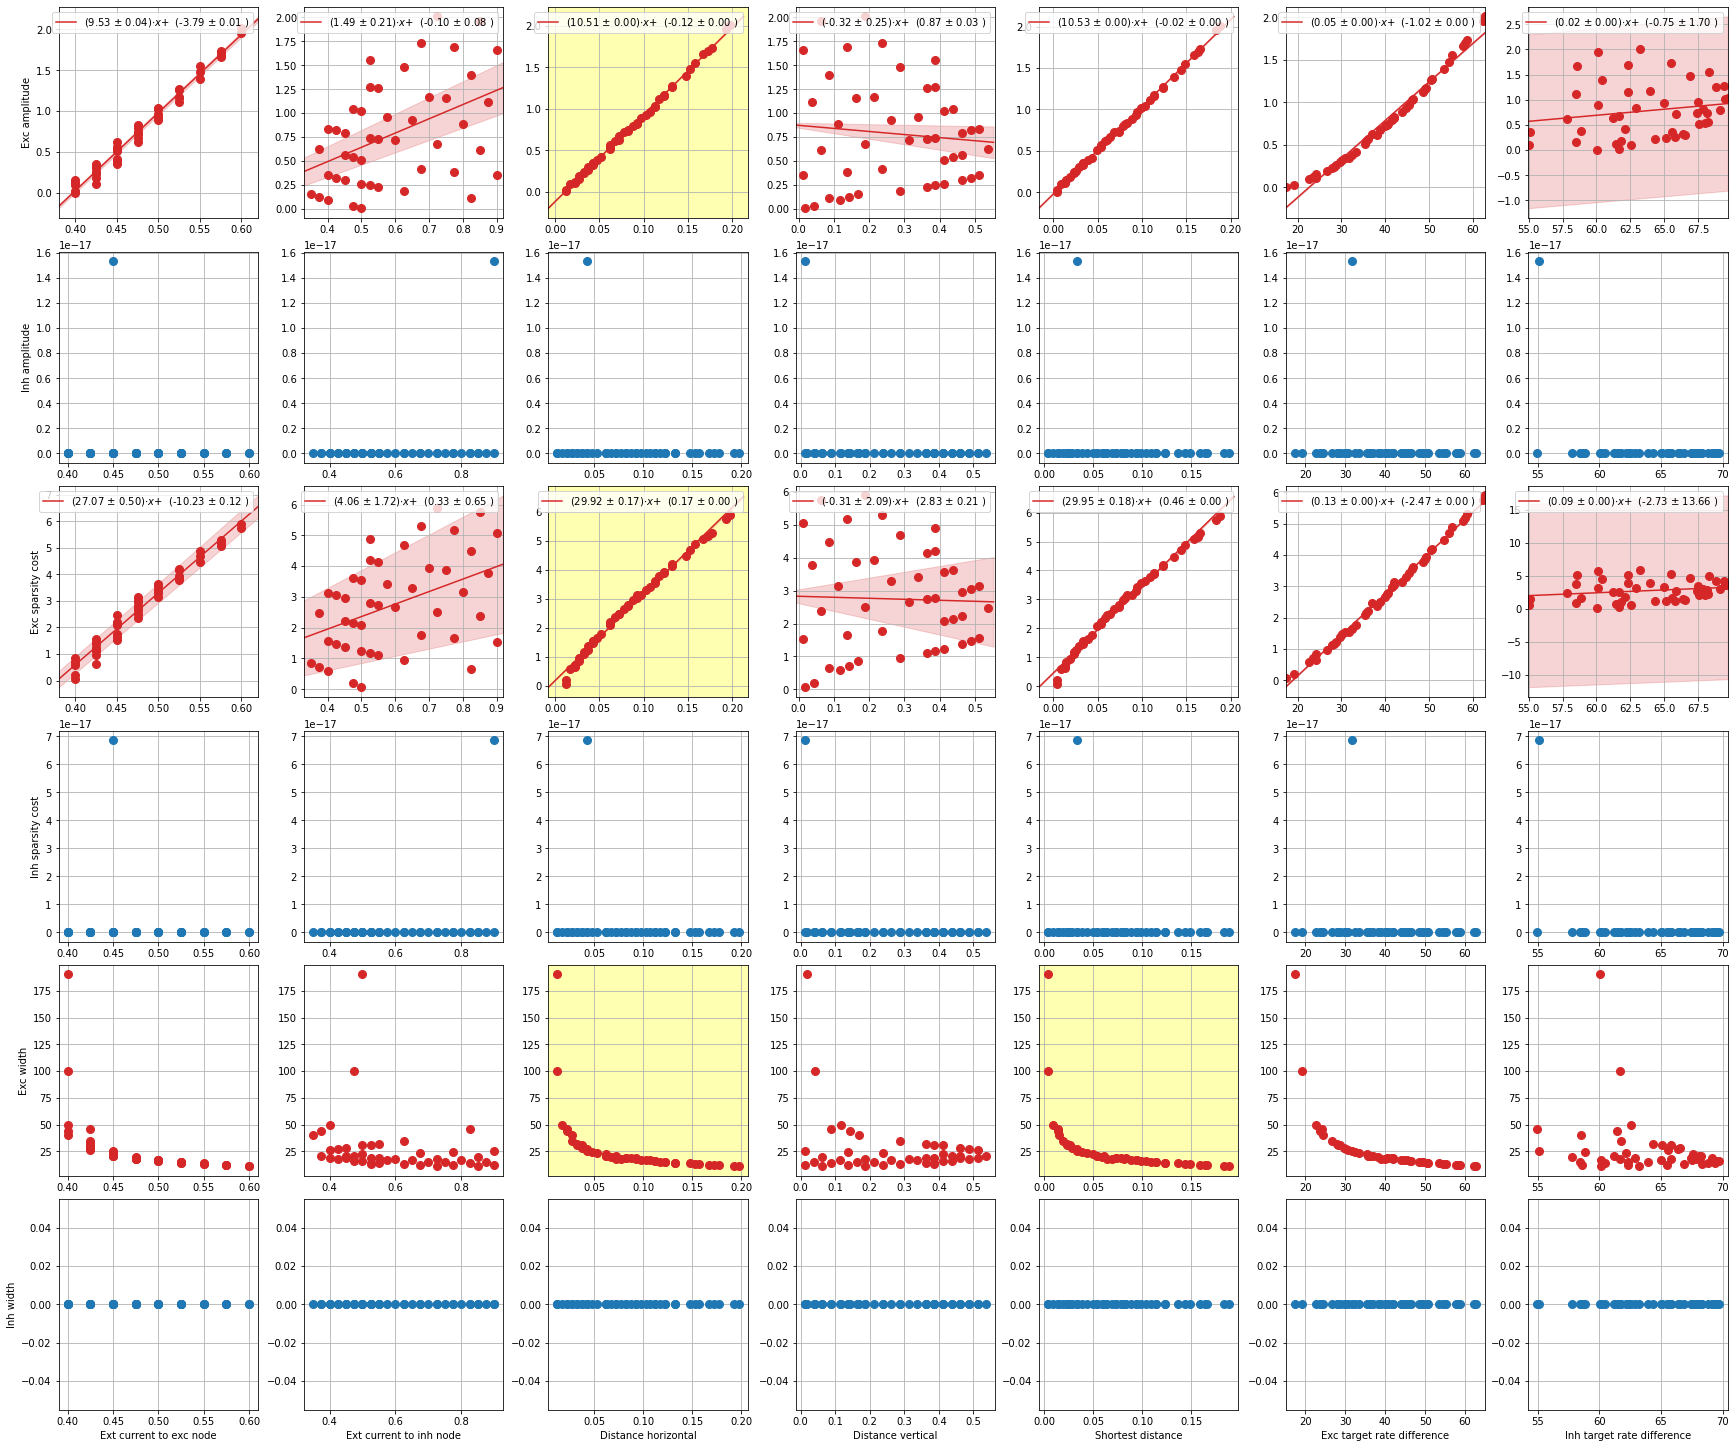

In [5]:
fig5c, axc = plt.subplots(6,7, constrained_layout=True, figsize = (24,20) )

markersize_ = 8

#########################################
readcase('3')

y_axis = [a_e, a_i, cost_s_x, cost_s_y, w_e, w_i]
x_axis = [mu_e, mu_i, d_e, d_i, d_total, target_diff_e, target_diff_i]

fit_data_y_e = [[], [], [], [], [], []]
fit_data_y_i = [[], [], [], [], [], []]
fit_data_x_e = [[], [], [], [], [], [], []]
fit_data_x_i = [[], [], [], [], [], [], []]

fit_data = [[[None, None], [None, None], [None, None], [None, None], [None, None], [None, None], [None, None]],
            [[None, None], [None, None], [None, None], [None, None], [None, None], [None, None], [None, None]],
            [[None, None], [None, None], [None, None], [None, None], [None, None], [None, None], [None, None]],
            [[None, None], [None, None], [None, None], [None, None], [None, None], [None, None], [None, None]],
            [[None, None], [None, None], [None, None], [None, None], [None, None], [None, None], [None, None]],
            [[None, None], [None, None], [None, None], [None, None], [None, None], [None, None], [None, None]]]

#fit_data[6][7][2]= 1.

for i in range(len(d_e)):
    if type(a_e[i]) == type(None):
        continue

    if np.abs(a_i[i]) > np.abs(a_e[i]):
        marker_ = 'x'
    else:
        marker_ = 'o'
        
    for x_ in range(len(x_axis)):
        x_data = x_axis[x_][i]
        if np.abs(a_i[i]) > np.abs(a_e[i]):
            fit_data_x_i[x_].append(x_data)
        elif np.abs(a_i[i]) <= np.abs(a_e[i]):
            fit_data_x_e[x_].append(x_data)
                
    for y_ in range(len(y_axis)):
        
        if y_ in [0,2,4]:
            color_ = exc_red
        else:
            color_ = inh_blue
        
        y_data = np.abs(y_axis[y_][i])
        if np.abs(a_i[i]) > np.abs(a_e[i]):
            fit_data_y_i[y_].append(y_data)
        elif np.abs(a_i[i]) <= np.abs(a_e[i]):
            fit_data_y_e[y_].append(y_data)
        
        for x_ in range(len(x_axis)):
            x_data = x_axis[x_][i]
        
            axc[y_,x_].plot(x_data, y_data, marker=marker_, color=color_, markersize=markersize_)
            
x_min_max = [[np.amin(x_) - 0.02, np.amax(x_) + 0.02] for x_ in fit_data_x_e]
x_ranges = [np.arange(x_min_max[x_][0], x_min_max[x_][1], 0.01) for x_ in range(len(x_min_max))]

for x_ in range(len(x_axis)):
    for y_ in range(len(y_axis)):
        
        if y_ in [1,3,4,5]:
            continue
        
        color_ = exc_red
        popt, pcov = curve_fit(fit_func_lin, fit_data_x_e[x_], fit_data_y_e[y_])
                        
        fit_data[y_][x_][0] = popt
        fit_data[y_][x_][1] = pcov
        label_ = ('({:.2f} '.format(fit_data[y_][x_][0][0]) + r'$\pm$' + ' {:.2f}'.format(fit_data[y_][x_][1][0,0])
                  + r')$\cdot x $+ ' + ' ({:.2f} '.format(fit_data[y_][x_][0][1]) + r'$\pm$'
                  + ' {:.2f} '.format(fit_data[y_][x_][1][1,1])
                  + ')'
                )
        axc[y_,x_].plot(x_ranges[x_], fit_func_lin(x_ranges[x_], fit_data[y_][x_][0][0], fit_data[y_][x_][0][1]),
                       color=color_, label = label_)
        axc[y_,x_].fill_between(x_ranges[x_], fit_func_lin(x_ranges[x_],
                fit_data[y_][x_][0][0] - fit_data[y_][x_][1][0,0], fit_data[y_][x_][0][1] - fit_data[y_][x_][1][1,1]),
                fit_func_lin(x_ranges[x_],
                fit_data[y_][x_][0][0] + fit_data[y_][x_][1][0,0], fit_data[y_][x_][0][1] + fit_data[y_][x_][1][1,1]),
                color=color_, alpha=0.2)
        
        axc[y_,x_].set_xlim(x_min_max[x_])
        axc[y_,x_].legend(loc='upper right')
        
plot_yellow = [[0,2], [2,2], [4,2], [4,4]]

for i in range(len(plot_yellow)):
    axc[plot_yellow[i][0], plot_yellow[i][1]].patch.set_facecolor('yellow')
    axc[plot_yellow[i][0], plot_yellow[i][1]].patch.set_alpha(0.3)

setlabels(axc)
       
plt.savefig( os.path.join(os.getcwd(), 'All_3.png') )
plt.savefig( os.path.join(savepath, 'All_3.png') )
plt.show()

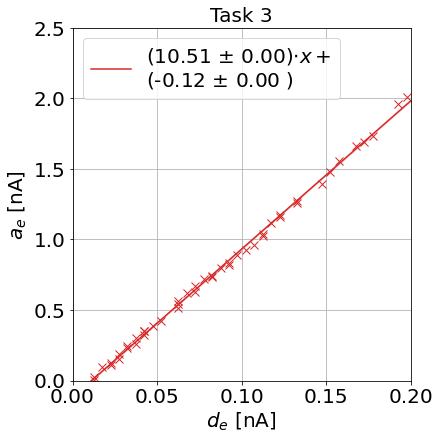

In [6]:
fig_1, ax = plt.subplots(1,1, constrained_layout=True, figsize = (6,6) )
fontsize_ = 20

for i in range(len(d_e)):
    if type(a_e[i]) == type(None):
        continue

    if np.abs(a_i[i]) < np.abs(a_e[i]):
        marker_ = 'x'
        color_ = exc_red
        ax.plot(d_e[i], np.abs(a_e[i]), marker=marker_, color=color_, markersize=markersize_)

label_ = ('({:.2f} '.format(fit_data[0][2][0][0]) + r'$\pm$' + ' {:.2f}'.format(fit_data[0][2][1][0,0])
                  + r')$\cdot x +$' + '\n'  + '({:.2f} '.format(fit_data[0][2][0][1]) + r'$\pm$'
                  + ' {:.2f} '.format(fit_data[0][2][1][1,1])
                  + ')'
                )
ax.plot(x_ranges[2], fit_func_lin(x_ranges[2], fit_data[0][2][0][0], fit_data[0][2][0][1]),
                       color=exc_red, label = label_)
ax.fill_between(x_ranges[2], fit_func_lin(x_ranges[2],
                fit_data[0][2][0][0] - fit_data[0][2][1][0,0], fit_data[0][2][0][1] - fit_data[0][2][1][1,1]),
                fit_func_lin(x_ranges[2],
                fit_data[0][2][0][0] + fit_data[0][2][1][0,0], fit_data[0][2][0][1] + fit_data[0][2][1][1,1]),
               color=exc_red, alpha=0.2)
        
ax.set_xlim(0., 0.2)
ax. set_ylim(0., 2.5)
ax.legend(loc='upper left', fontsize=fontsize_)

ax.set_xlabel(r'$d_e$ [nA]', fontsize=fontsize_)
ax.set_ylabel(r'$a_e$ [nA]', fontsize=fontsize_)
ax.tick_params(axis='x', labelsize=fontsize_)
ax.tick_params(axis='y', labelsize=fontsize_)
ax.set_title('Task 3', fontsize=fontsize_)

plt.savefig( os.path.join(os.getcwd(), 'amplitude_3.png') )
plt.savefig( os.path.join(savepath, 'amplitude_3.png') )

plt.show()

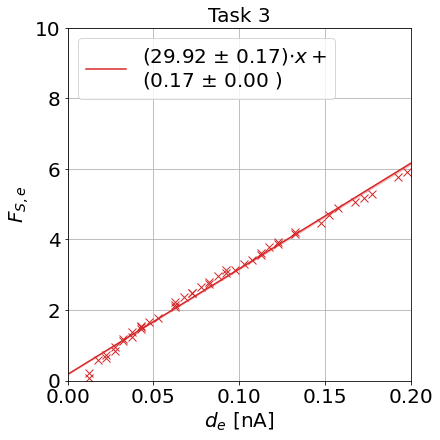

In [7]:
fig_1, ax = plt.subplots(1,1, constrained_layout=True, figsize = (6,6) )
fontsize_ = 20

for i in range(len(d_e)):
    if type(a_e[i]) == type(None):
        continue

    if np.abs(a_i[i]) < np.abs(a_e[i]):
        marker_ = 'x'
        color_ = exc_red
        ax.plot(d_e[i], np.abs(cost_s_x[i]), marker=marker_, color=color_, markersize=markersize_)

label_ = ('({:.2f} '.format(fit_data[2][2][0][0]) + r'$\pm$' + ' {:.2f}'.format(fit_data[2][2][1][0,0])
                  + r')$\cdot x +$' + '\n'  + '({:.2f} '.format(fit_data[2][2][0][1]) + r'$\pm$'
                  + ' {:.2f} '.format(fit_data[2][2][1][1,1])
                  + ')'
                )
ax.plot(x_ranges[2], fit_func_lin(x_ranges[2], fit_data[2][2][0][0], fit_data[2][2][0][1]),
                       color=exc_red, label = label_)
ax.fill_between(x_ranges[2], fit_func_lin(x_ranges[2],
                fit_data[2][2][0][0] - fit_data[2][2][1][0,0], fit_data[2][2][0][1] - fit_data[2][2][1][1,1]),
                fit_func_lin(x_ranges[2],
                fit_data[2][2][0][0] + fit_data[2][2][1][0,0], fit_data[2][2][0][1] + fit_data[2][2][1][1,1]),
               color=exc_red, alpha=0.2)
        
ax.set_xlim(0., 0.2)
ax. set_ylim(0., 10.)
ax.legend(loc='upper left', fontsize=fontsize_)

ax.set_xlabel(r'$d_e$ [nA]', fontsize=fontsize_)
ax.set_ylabel(r'$F_{S,e}$', fontsize=fontsize_)
ax.tick_params(axis='x', labelsize=fontsize_)
ax.tick_params(axis='y', labelsize=fontsize_)
ax.set_title('Task 3', fontsize=fontsize_)

plt.savefig( os.path.join(os.getcwd(), 'cost_3.png') )
plt.savefig( os.path.join(savepath, 'cost_3.png') )

plt.show()

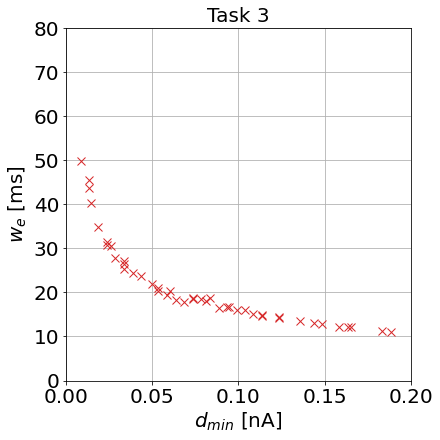

In [8]:
fig_1, ax = plt.subplots(1,1, constrained_layout=True, figsize = (6,6) )
fontsize_ = 20

for i in range(len(d_e)):
    if type(a_e[i]) == type(None):
        continue

    if np.abs(a_i[i]) < np.abs(a_e[i]):
        marker_ = 'x'
        color_ = exc_red
        ax.plot(d_total[i], np.abs(w_e[i]), marker=marker_, color=color_, markersize=markersize_)
        
ax.set_xlim(0., 0.2)
ax. set_ylim(0., 80.)

ax.set_xlabel(r'$d_{min}$ [nA]', fontsize=fontsize_)
ax.set_ylabel(r'$w_e$ [ms]', fontsize=fontsize_)
ax.tick_params(axis='x', labelsize=fontsize_)
ax.tick_params(axis='y', labelsize=fontsize_)
ax.set_title('Task 3', fontsize=fontsize_)

plt.savefig( os.path.join(os.getcwd(), 'width_3.png') )
plt.savefig( os.path.join(savepath, 'width_3.png') )

plt.show()

In [ ]:
fig5c, axc = plt.subplots(6,8, constrained_layout=True, figsize = (36,30) )

ufp_diff_e_low = [None] * len(a_e)
ufp_diff_i_low = [None] * len(a_e)
ufp_diff_e_high = [None] * len(a_e)
ufp_diff_i_high = [None] * len(a_e)
ufp_ratio_e = [None] * len(a_e)
ufp_ratio_i = [None] * len(a_e)

for i in range(len(d_e)):
    if type(ufp_e[i]) == type(None):
        continue
    ufp_diff_e_low[i] = np.abs(ufp_e[i] - target_l_e[i])
    ufp_diff_i_low[i] = np.abs(ufp_i[i] - target_l_i[i])
    ufp_diff_e_high[i] = np.abs(ufp_e[i] - target_h_e[i])
    ufp_diff_i_high[i] = np.abs(ufp_i[i] - target_h_i[i])
    ufp_ratio_e[i] = ufp_e[i] / np.abs(target_h_e[i] - target_l_e[i])
    ufp_ratio_i[i] = ufp_i[i] / np.abs(target_h_i[i] - target_l_i[i])

y_axis = [a_e, a_i, cost_s_x, cost_s_y, w_e, w_i]
x_axis = [ufp_e, ufp_i, ufp_diff_e_low, ufp_diff_i_low, ufp_diff_e_high, ufp_diff_i_high, ufp_ratio_e, ufp_ratio_i]

fit_data_y_e = [[], [], [], [], [], []]
fit_data_x_e = [[], [], [], [], [], [], [], []]

fit_data = [[[None, None], [None, None], [None, None], [None, None], [None, None], [None, None], [None, None], [None, None]],
            [[None, None], [None, None], [None, None], [None, None], [None, None], [None, None], [None, None], [None, None]],
            [[None, None], [None, None], [None, None], [None, None], [None, None], [None, None], [None, None], [None, None]],
            [[None, None], [None, None], [None, None], [None, None], [None, None], [None, None], [None, None], [None, None]],
            [[None, None], [None, None], [None, None], [None, None], [None, None], [None, None], [None, None], [None, None]],
            [[None, None], [None, None], [None, None], [None, None], [None, None], [None, None], [None, None], [None, None]]]

#fit_data[6][7][2]= 1.

for i in range(len(d_e)):
    if type(ufp_e[i]) == type(None):
        continue

    if np.abs(a_i[i]) > np.abs(a_e[i]):
        marker_ = 'x'
    else:
        marker_ = 'o'
        
    for x_ in range(len(x_axis)):
        x_data = x_axis[x_][i]
        if np.abs(a_i[i]) <= np.abs(a_e[i]):
            fit_data_x_e[x_].append(x_data)
                
    for y_ in range(len(y_axis)):
        
        if y_ in [0,2,4]:
            color_ = exc_red
        else:
            color_ = inh_blue
        
        y_data = np.abs(y_axis[y_][i])
        if np.abs(a_i[i]) <= np.abs(a_e[i]):
            fit_data_y_e[y_].append(y_data)
        
        for x_ in range(len(x_axis)):
            x_data = x_axis[x_][i]
        
            axc[y_,x_].plot(x_data, y_data, marker=marker_, color=color_, markersize=markersize_)

print(fit_data_y_i)
            
x_min_max = [[np.amin(x_) - 0.02, np.amax(x_) + 0.02] for x_ in fit_data_x_e]
x_ranges = [np.arange(x_min_max[x_][0], x_min_max[x_][1], 0.01) for x_ in range(len(x_min_max))]

for x_ in range(len(x_axis)):
    for y_ in range(len(y_axis)):
        
        if y_ in [1,3,4,5]:
            continue
        
        color_ = exc_red
        popt, pcov = curve_fit(fit_func_lin, fit_data_x_e[x_], fit_data_y_e[y_])
                        
        fit_data[y_][x_][0] = popt
        fit_data[y_][x_][1] = pcov
        label_ = ('({:.4f} '.format(fit_data[y_][x_][0][0]) + r'$\pm$' + ' {:.4f}'.format(fit_data[y_][x_][1][0,0])
                  + r')$\cdot x $+ ' + ' ({:.4f} '.format(fit_data[y_][x_][0][1]) + r'$\pm$'
                  + ' {:.4f} '.format(fit_data[y_][x_][1][1,1])
                  + ')'
                )
        axc[y_,x_].plot(x_ranges[x_], fit_func_lin(x_ranges[x_], fit_data[y_][x_][0][0], fit_data[y_][x_][0][1]),
                       color=color_, label = label_)
        axc[y_,x_].fill_between(x_ranges[x_], fit_func_lin(x_ranges[x_],
                fit_data[y_][x_][0][0] - fit_data[y_][x_][1][0,0], fit_data[y_][x_][0][1] - fit_data[y_][x_][1][1,1]),
                fit_func_lin(x_ranges[x_],
                fit_data[y_][x_][0][0] + fit_data[y_][x_][1][0,0], fit_data[y_][x_][0][1] + fit_data[y_][x_][1][1,1]),
                color=color_, alpha=0.2)
        
        axc[y_,x_].set_xlim(x_min_max[x_])
        axc[y_,x_].legend(loc='upper right')
        
plot_yellow = [[0,3], [0,4], [0,6], [2,3], [2,4], [2,6], [4,4], [4,6]]

for i in range(len(plot_yellow)):
    axc[plot_yellow[i][0], plot_yellow[i][1]].patch.set_facecolor('yellow')
    axc[plot_yellow[i][0], plot_yellow[i][1]].patch.set_alpha(0.3)

setlabels_ufp(axc)
       
plt.savefig( os.path.join(os.getcwd(), 'UFP_3.png') )
plt.savefig( os.path.join(savepath, 'UFP_3.png') )
plt.show()